## preparation

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone

from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "abrambeyer/openintro-possum",
    "possum.csv"
)

df.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


### keep cleaning the dataset

In [3]:
df = df.dropna().copy()
df = df.drop(columns=["case"])
df["site"] = df["site"].astype(str)

In [4]:
print("Shape:", df.shape)
df.head()

Shape: (101, 13)


,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


## multiple linear regression model

### define target and features

In [5]:
X = df.drop(columns=["age"])
y = df["age"]

In [6]:
categorical_features = ["Pop", "sex", "site"]

numerical_features = [
    "hdlngth", "skullw", "totlngth", "taill",
    "footlgth", "earconch", "eye", "chest", "belly"
]

### train-test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

The dataset was split into a training set and a testing set. 80% of the data was used for training, and 20% was used for testing.

### preprocessing

In [8]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [9]:
def build_model(estimator):
    return Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", estimator)
    ])


def evaluate_predictions(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


def get_coefficient_table(model):
    feature_names = model.named_steps["preprocessor"].get_feature_names_out()
    coefficients = model.named_steps["model"].coef_

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
    return coef_df.sort_values("Abs_Coefficient", ascending=False)

### build multiple linear regression model

In [10]:
linear_model = build_model(LinearRegression())
linear_model.fit(X_train, y_train);

### assessment

In [11]:
y_pred = linear_model.predict(X_test)
linear_results = evaluate_predictions(
    y_test,
    y_pred,
    "Multiple Linear Regression"
)

pd.DataFrame([linear_results])

,Model,MAE,RMSE,R2
0,Multiple Linear Regression,1.549344,2.093992,0.030242


MAE = 1.55 means that the model’s prediction is wrong by about 1.55 years on average.

RMSE = 2.09, which is higher than the MAE. This suggests that some predictions had relatively large errors.

R-squared = 0.03, meaning that the model explained only about 3% of the variation in possum age. This indicates weak explanatory power.

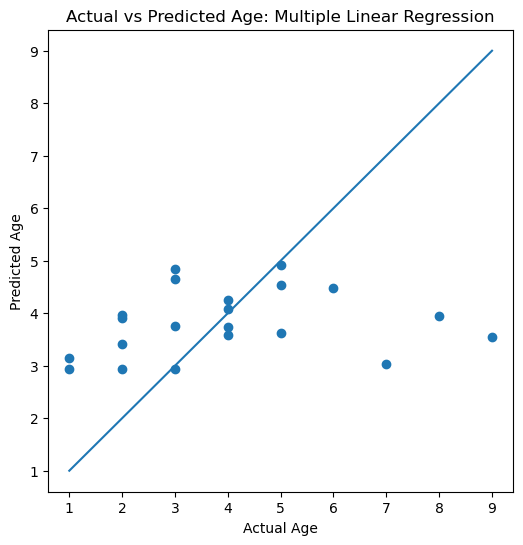

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Actual vs Predicted Age: Multiple Linear Regression")

min_age = min(y_test.min(), y_pred.min())
max_age = max(y_test.max(), y_pred.max())

plt.plot([min_age, max_age], [min_age, max_age])

plt.show()

The points are widely scattered, it means that the model's predictions are not very accurate.

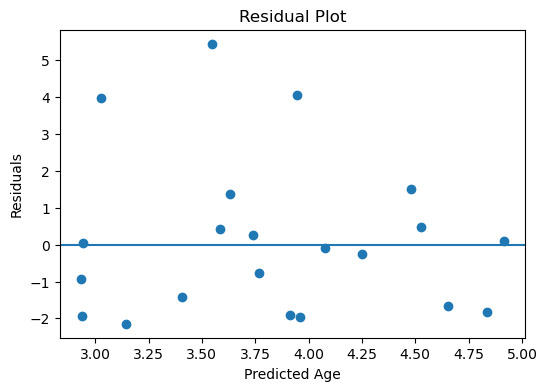

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals)
plt.axhline(0)

plt.xlabel("Predicted Age")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

The residual plot shows the prediction errors of the multiple linear regression model. Ideally, the residuals should be randomly scattered around zero. In this plot, the residuals are spread out, which indicates that the model has relatively large prediction errors and does **NOT** fit the data very well.

In [14]:
linear_coef_df = get_coefficient_table(linear_model)
linear_coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
9,cat__Pop_other,-2.096304,2.096304
13,cat__site_4,-1.552706,1.552706
4,num__footlgth,-1.168908,1.168908
11,cat__site_2,0.733167,0.733167
12,cat__site_3,-0.509169,0.509169
6,num__eye,0.435866,0.435866
16,cat__site_7,0.391012,0.391012
0,num__hdlngth,0.372972,0.372972
2,num__totlngth,0.325746,0.325746
8,num__belly,0.325531,0.325531


### little conclusion

The coefficients show the direction and relative strength of each predictor in the linear regression model. However, they should not be interpreted as causal effects. They only show associations within this dataset.

The multiple linear regression model had **limited** predictive power. Although the average error was relatively small, the **R² value** was very low, meaning that the model explained only a small proportion of the variation in possum age. This suggests that possum age **may not** be strongly related to the selected physical measurements in a simple linear way.

## lasso

### building model

In [15]:
lasso_model = build_model(Lasso(alpha=0.05, max_iter=10000))
lasso_model.fit(X_train, y_train);

### prediction

In [16]:
y_pred_lasso = lasso_model.predict(X_test)

### assessment

In [17]:
lasso_results = evaluate_predictions(
    y_test,
    y_pred_lasso,
    "Lasso Regression"
)

pd.DataFrame([lasso_results])

,Model,MAE,RMSE,R2
0,Lasso Regression,1.513747,1.995883,0.118984


Lasso Regression was selected as the **better** linear regression model because it had lower MAE, lower RMSE, and higher R² than the ordinary Multiple Linear Regression model.

 However, since the R² value was still low, the model should be interpreted as having **limited** predictive power.

### checking deleted coefficients

In [18]:
lasso_coef_df = get_coefficient_table(lasso_model)
deleted_lasso_coef_df = lasso_coef_df[lasso_coef_df["Coefficient"] == 0]

print("Deleted coefficients:", len(deleted_lasso_coef_df))
display(lasso_coef_df.head(10))
display(deleted_lasso_coef_df[["Feature", "Coefficient"]])

Deleted coefficients: 8


,Feature,Coefficient,Abs_Coefficient
13,cat__site_4,-0.620651,0.620651
4,num__footlgth,-0.325732,0.325732
8,num__belly,0.323065,0.323065
6,num__eye,0.309662,0.309662
0,num__hdlngth,0.252179,0.252179
7,num__chest,0.233204,0.233204
5,num__earconch,0.139758,0.139758
1,num__skullw,0.046530,0.046530
2,num__totlngth,0.043191,0.043191
3,num__taill,0.000000,0.000000


,Feature,Coefficient
3,num__taill,0.0
9,cat__Pop_other,-0.0
10,cat__sex_m,-0.0
11,cat__site_2,0.0
12,cat__site_3,-0.0
14,cat__site_5,-0.0
15,cat__site_6,0.0
16,cat__site_7,0.0


The LASSO regression delete **8** predictors whose coefficients were shrunk to zero. This makes the model simpler than ordinary multiple linear regression.

The strongest predictors retained in the model were **site_4**, **foot length**, **belly size**, and **eye size**, based on the magnitude of their coefficients.

## lassoCV

### building model

In [19]:
lasso_cv_model = build_model(
    LassoCV(
        alphas=[0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
        cv=5,
        max_iter=10000,
        random_state=42
    )
)

lasso_cv_model.fit(X_train, y_train);

### choosing best alpha

In [20]:
best_alpha = lasso_cv_model.named_steps["model"].alpha_
print("Best alpha:", best_alpha)

Best alpha: 1.0


The alpha value controls the strength of regularization. A larger alpha applies a stronger penalty and shrinks more coefficients toward zero. LassoCV automatically selects the best alpha through cross-validation.

### assessment

In [21]:
y_pred_lasso_cv = lasso_cv_model.predict(X_test)
lasso_cv_results = evaluate_predictions(
    y_test,
    y_pred_lasso_cv,
    "LassoCV Regression"
)

pd.DataFrame([lasso_cv_results])

,Model,MAE,RMSE,R2
0,LassoCV Regression,1.676786,2.132775,-0.006012


### checking deleted vavirables

In [22]:
lasso_cv_coef_df = get_coefficient_table(lasso_cv_model)
deleted_lasso_cv_coef_df = lasso_cv_coef_df[lasso_cv_coef_df["Coefficient"] == 0]
retained_lasso_cv_coef_df = lasso_cv_coef_df[lasso_cv_coef_df["Coefficient"] != 0]

print("Deleted coefficients:", len(deleted_lasso_cv_coef_df))
print("Retained coefficients:", len(retained_lasso_cv_coef_df))

display(retained_lasso_cv_coef_df[["Feature", "Coefficient", "Abs_Coefficient"]])
display(deleted_lasso_cv_coef_df[["Feature", "Coefficient"]])

Deleted coefficients: 17
Retained coefficients: 0


,Feature,Coefficient,Abs_Coefficient


,Feature,Coefficient
0,num__hdlngth,0.0
9,cat__Pop_other,-0.0
15,cat__site_6,-0.0
14,cat__site_5,0.0
13,cat__site_4,-0.0
12,cat__site_3,0.0
11,cat__site_2,-0.0
10,cat__sex_m,-0.0
8,num__belly,0.0
1,num__skullw,0.0


The LassoCV model shrank **all** predictor coefficients to zero. This means that, under the selected alpha value, the model did not retain any predictors and effectively became an intercept-only model. Therefore, LassoCV did **not** provide useful feature selection in this case.

### comparison

In [23]:
model_comparison = pd.DataFrame([
    linear_results,
    lasso_results,
    lasso_cv_results
])

model_comparison

,Model,MAE,RMSE,R2
0,Multiple Linear Regression,1.549344,2.093992,0.030242
1,Lasso Regression,1.513747,1.995883,0.118984
2,LassoCV Regression,1.676786,2.132775,-0.006012


Among the three models, ordinary Lasso Regression performed the best. It had the lowest MAE and RMSE, and the highest R². Compared with Multiple Linear Regression, Lasso reduced the average prediction error and explained more variation in possum age. In contrast, LassoCV performed worse than both models, with a higher MAE and RMSE and a negative R² value.

Therefore, based on the test set results, **ordinary Lasso Regression** was the best-performing model.

Although LassoCV is more systematic because it selects the alpha value through cross-validation, it did not perform well on this test set. This may be due to the small sample size and the sensitivity of the train-test split.

### standardized heat map

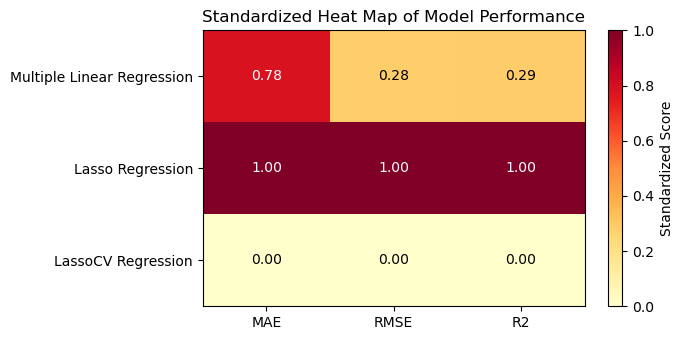

In [24]:
heatmap_df = model_comparison.set_index("Model")

standardized_heatmap = pd.DataFrame(index=heatmap_df.index)

for metric in heatmap_df.columns:
    values = heatmap_df[metric]
    value_range = values.max() - values.min()

    if value_range == 0:
        standardized_heatmap[metric] = 1
    elif metric in ["MAE", "RMSE"]:
        standardized_heatmap[metric] = (values.max() - values) / value_range
    else:
        standardized_heatmap[metric] = (values - values.min()) / value_range

data = standardized_heatmap.values

plt.figure(figsize=(7, 3.5))

plt.imshow(data, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)

plt.xticks(
    np.arange(len(standardized_heatmap.columns)),
    standardized_heatmap.columns
)
plt.yticks(
    np.arange(len(standardized_heatmap.index)),
    standardized_heatmap.index
)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        text_color = "white" if data[i, j] > 0.55 else "black"
        plt.text(
            j,
            i,
            f"{data[i, j]:.2f}",
            ha="center",
            va="center",
            color=text_color
        )

plt.title("Standardized Heat Map of Model Performance")
plt.colorbar(label="Standardized Score")
plt.tight_layout()
plt.show()

The standardized heat map compares the performance of the three models across MAE, RMSE, and R². A higher standardized score means better performance. 

**Lasso Regression** performs the **best** overall, with a score of 1.00 for all three metrics. 

**Multiple Linear Regression** has **moderate** performance, especially for MAE, but its RMSE and R² scores are much lower. 

**LassoCV Regression** performs the **worst** in this comparison, with the lowest standardized scores across all metrics.

## Further work(EDA)

### correlation heat map

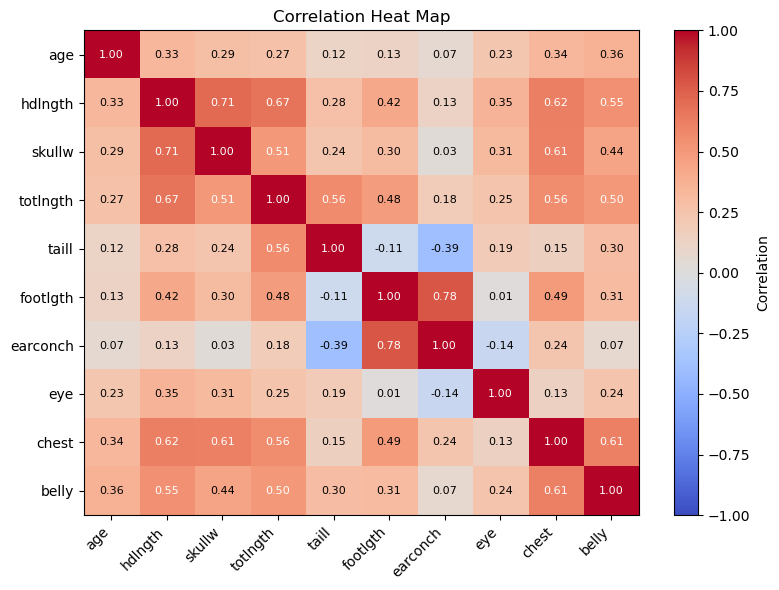

In [25]:
corr_df = df.select_dtypes(include=["int64", "float64"]).corr()
data = corr_df.values

plt.figure(figsize=(8, 6))
plt.imshow(data, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")

plt.xticks(np.arange(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
plt.yticks(np.arange(len(corr_df.index)), corr_df.index)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        text_color = "white" if abs(data[i, j]) > 0.5 else "black"
        plt.text(
            j,
            i,
            f"{data[i, j]:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8
        )

plt.title("Correlation Heat Map")
plt.colorbar(label="Correlation")
plt.tight_layout()
plt.show()

## Random Forest Regression

### building model

In [26]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = build_model(
    RandomForestRegressor(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=3,
        random_state=42
    )
)

random_forest_model.fit(X_train, y_train);

### assessment

In [27]:
y_pred_random_forest = random_forest_model.predict(X_test)

random_forest_results = evaluate_predictions(
    y_test,
    y_pred_random_forest,
    "Random Forest Regression"
)

pd.DataFrame([random_forest_results])

,Model,MAE,RMSE,R2
0,Random Forest Regression,1.332157,1.715237,0.349328


### comparison

In [28]:
y_pred_linear = linear_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)
y_pred_lasso_cv = lasso_cv_model.predict(X_test)
y_pred_random_forest = random_forest_model.predict(X_test)

linear_results = evaluate_predictions(
    y_test,
    y_pred_linear,
    "Multiple Linear Regression"
)

lasso_results = evaluate_predictions(
    y_test,
    y_pred_lasso,
    "Lasso Regression"
)

lasso_cv_results = evaluate_predictions(
    y_test,
    y_pred_lasso_cv,
    "LassoCV Regression"
)

random_forest_results = evaluate_predictions(
    y_test,
    y_pred_random_forest,
    "Random Forest Regression"
)

model_comparison = pd.DataFrame([
    linear_results,
    lasso_results,
    lasso_cv_results,
    random_forest_results
])

model_comparison

,Model,MAE,RMSE,R2
0,Multiple Linear Regression,1.549344,2.093992,0.030242
1,Lasso Regression,1.513747,1.995883,0.118984
2,LassoCV Regression,1.676786,2.132775,-0.006012
3,Random Forest Regression,1.332157,1.715237,0.349328


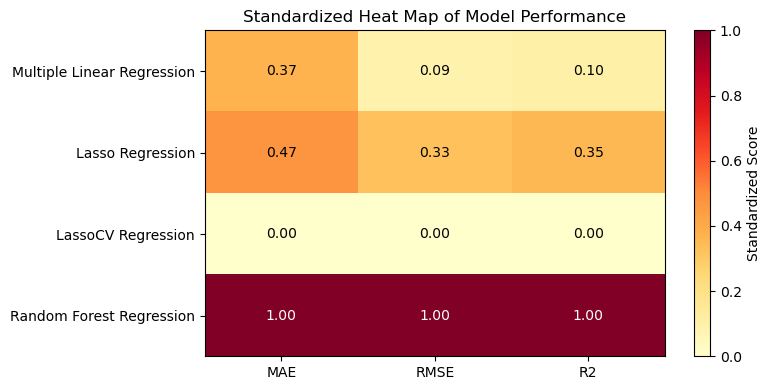

In [29]:
heatmap_df = model_comparison.set_index("Model")

standardized_heatmap = pd.DataFrame(index=heatmap_df.index)

for metric in heatmap_df.columns:
    values = heatmap_df[metric]
    value_range = values.max() - values.min()

    if value_range == 0:
        standardized_heatmap[metric] = 1
    elif metric in ["MAE", "RMSE"]:
        standardized_heatmap[metric] = (values.max() - values) / value_range
    else:
        standardized_heatmap[metric] = (values - values.min()) / value_range

data = standardized_heatmap.values

plt.figure(figsize=(8, 4))

plt.imshow(data, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)

plt.xticks(
    np.arange(len(standardized_heatmap.columns)),
    standardized_heatmap.columns
)

plt.yticks(
    np.arange(len(standardized_heatmap.index)),
    standardized_heatmap.index
)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        text_color = "white" if data[i, j] > 0.55 else "black"
        plt.text(
            j,
            i,
            f"{data[i, j]:.2f}",
            ha="center",
            va="center",
            color=text_color
        )

plt.title("Standardized Heat Map of Model Performance")
plt.colorbar(label="Standardized Score")
plt.tight_layout()
plt.show()

The standardized heat map shows that **Random Forest Regression** performs the **best** among the four models. It has the highest standardized score of 1.00 for MAE, RMSE, and R², which means it has the lowest prediction errors and the highest explanatory power in this comparison. Lasso Regression performs better than Multiple Linear Regression overall, especially for RMSE and R². Multiple Linear Regression has weaker performance, while LassoCV Regression performs the worst across all three metrics.

### scatter plot

In [30]:
y_pred_lasso_all = lasso_model.predict(X)
y_pred_random_forest_all = random_forest_model.predict(X)

residuals_lasso_all = y - y_pred_lasso_all
residuals_random_forest_all = y - y_pred_random_forest_all

#### actual vs predicted age 

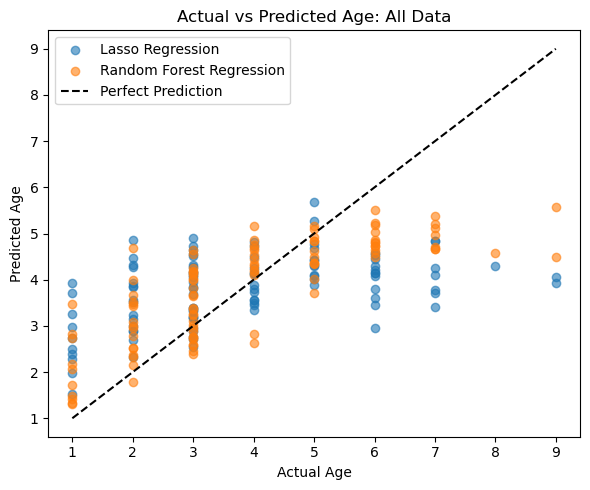

In [31]:
min_age = min(y.min(), y_pred_lasso_all.min(), y_pred_random_forest_all.min())
max_age = max(y.max(), y_pred_lasso_all.max(), y_pred_random_forest_all.max())

plt.figure(figsize=(6, 5))

plt.scatter(
    y,
    y_pred_lasso_all,
    label="Lasso Regression",
    alpha=0.6
)

plt.scatter(
    y,
    y_pred_random_forest_all,
    label="Random Forest Regression",
    alpha=0.6
)

plt.plot(
    [min_age, max_age],
    [min_age, max_age],
    linestyle="--",
    color="black",
    label="Perfect Prediction"
)

plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Actual vs Predicted Age: All Data")
plt.legend()
plt.tight_layout()
plt.show()

#### residual plot

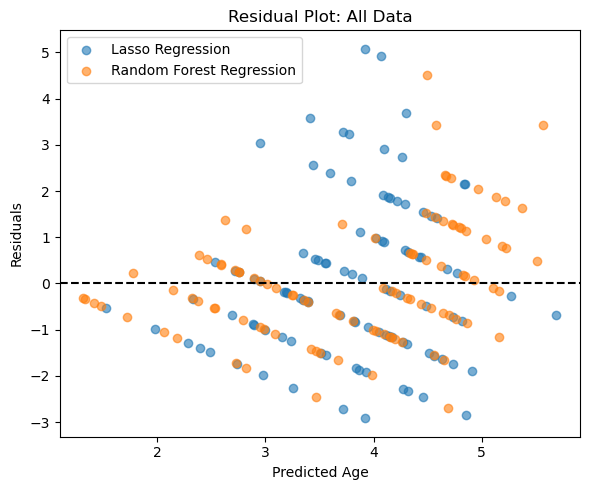

In [32]:
plt.figure(figsize=(6, 5))

plt.scatter(
    y_pred_lasso_all,
    residuals_lasso_all,
    label="Lasso Regression",
    alpha=0.6
)

plt.scatter(
    y_pred_random_forest_all,
    residuals_random_forest_all,
    label="Random Forest Regression",
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--",
    color="black"
)

plt.xlabel("Predicted Age")
plt.ylabel("Residuals")
plt.title("Residual Plot: All Data")
plt.legend()
plt.tight_layout()
plt.show()

## Summary of the Modeling Process

After cleaning the raw data, I obtained the final dataset for analysis. I first built a **multiple linear regression model**, but the results were only moderate. The model did not fit the data particularly well, suggesting that a simple linear approach might not fully capture the patterns in the dataset.

To improve the model performance, I then applied **Lasso regression**. Compared with the multiple linear regression model, Lasso performed slightly better. This suggests that regularization helped reduce noise and improve the model to some extent.

Next, I tried to further improve the result by using **LassoCV**, which automatically selects the best alpha value through cross-validation. However, the alpha selected by LassoCV was too strong, causing all coefficients to shrink to zero. As a result, the model removed all useful predictors and could not be effectively used.

Overall, among the regression-based models, **Lasso regression produced the best result**, although its performance was still limited. 

As part of the **exploratory data analysis (EDA)**, I also created a **correlation heat map** to better understand the relationships between variables. The heat map suggested that the data might contain more complex and non-linear patterns, which may not be well captured by linear regression models. Therefore, I decided to try a **Random Forest model**.

**The Random Forest model achieved the best performance** among all the models. This indicates that it was more suitable for this dataset, especially because it can capture non-linear relationships and interactions between variables more effectively than linear models.

In conclusion, although Lasso regression improved the results compared with multiple linear regression, the overall performance of linear models remained limited. The Random Forest model provided the best result and appeared to be the most appropriate model for this dataset.